In [3]:
#import libraries
import pandas as pd #load and work wth dataset
import matplotlib.pyplot as plt #used to draw graphs
import seaborn as sns #makes graphs pretier
from scipy.stats import ttest_ind #function that performs the A/B statical test

In [4]:
df = pd.read_csv('A_B_testing_dataset.csv')

In [5]:
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57


In [6]:
df.shape

(1000, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date_of_campaign          1000 non-null   object 
 1   facebook_ad_campaign      1000 non-null   object 
 2   facebook_ad_views         1000 non-null   int64  
 3   facebook_ad_clicks        1000 non-null   int64  
 4   facebook_ad_conversions   1000 non-null   int64  
 5   facebook_cost_per_ad      1000 non-null   int64  
 6   facebook_ctr              1000 non-null   float64
 7   facebook_conversion_rate  1000 non-null   float64
 8   facebook_cost_per_click   1000 non-null   float64
 9   adword_ad_campaign        1000 non-null   object 
 10  adword_ad_views           1000 non-null   int64  
 11  adword_ad_clicks          1000 non-null   int64  
 12  adword_ad_conversions     1000 non-null   int64  
 13  adword_cost_per_ad        1000 non-null   int64  
 14  adword_ct

In [9]:
#Split the dataset into Group A and Group B, because A/B Testing must compare two groups.
# Group A: Facebook ads data
facebook = df[[
    'facebook_ad_views',
    'facebook_ad_clicks',
    'facebook_ad_conversions',
    'facebook_cost_per_ad',
    'facebook_ctr',
    'facebook_conversion_rate',
    'facebook_cost_per_click'
]]

# Group B: AdWords ads data
adwords = df[[
    'adword_ad_views',
    'adword_ad_clicks',
    'adword_ad_conversions',
    'adword_cost_per_ad',
    'adword_ctr',
    'adword_conversion_rate',
    'adword_cost_per_click'
]]


In [10]:
#Calculate Averages for Both Groups
#Compare Click-Through Rate (CTR)
facebook_ctr_mean = facebook['facebook_ctr'].mean()
adwords_ctr_mean = adwords['adword_ctr'].mean()

facebook_ctr_mean, adwords_ctr_mean


(np.float64(2.2831599999999996), np.float64(1.28095))

In [11]:
#Compare Conversion Rate, which platform turns clicks into purchases better
facebook_conv_mean = facebook['facebook_conversion_rate'].mean()
adwords_conv_mean = adwords['adword_conversion_rate'].mean()

facebook_conv_mean, adwords_conv_mean


(np.float64(32.69608), np.float64(10.80751))

In [12]:
#Compare Cost Per Click (CPC). Lower CPC = cheaper traffic (We compare the cost efficiency of each ad platform)
facebook_cpc_mean = facebook['facebook_cost_per_click'].mean()
adwords_cpc_mean = adwords['adword_cost_per_click'].mean()

facebook_cpc_mean, adwords_cpc_mean


(np.float64(4.3105), np.float64(2.26554))

In [13]:
#A/B Test for CTR
t_ctr, p_ctr = ttest_ind(
    facebook['facebook_ctr'],
    adwords['adword_ctr'],
    equal_var=False
)

t_ctr, p_ctr


(np.float64(24.914527350282636), np.float64(4.489219631688428e-111))

In [14]:
#A/B Test for Conversion Rate
t_conv, p_conv = ttest_ind(
    facebook['facebook_conversion_rate'],
    adwords['adword_conversion_rate'],
    equal_var=False
)

t_conv, p_conv


(np.float64(32.62045547744514), np.float64(7.116026506592085e-165))

In [15]:
#A/B Test for Cost Per Click (CPC)
t_cpc, p_cpc = ttest_ind(
    facebook['facebook_cost_per_click'],
    adwords['adword_cost_per_click'],
    equal_var=False
)

t_cpc, p_cpc


(np.float64(21.81761965852683), np.float64(2.790108005850851e-90))

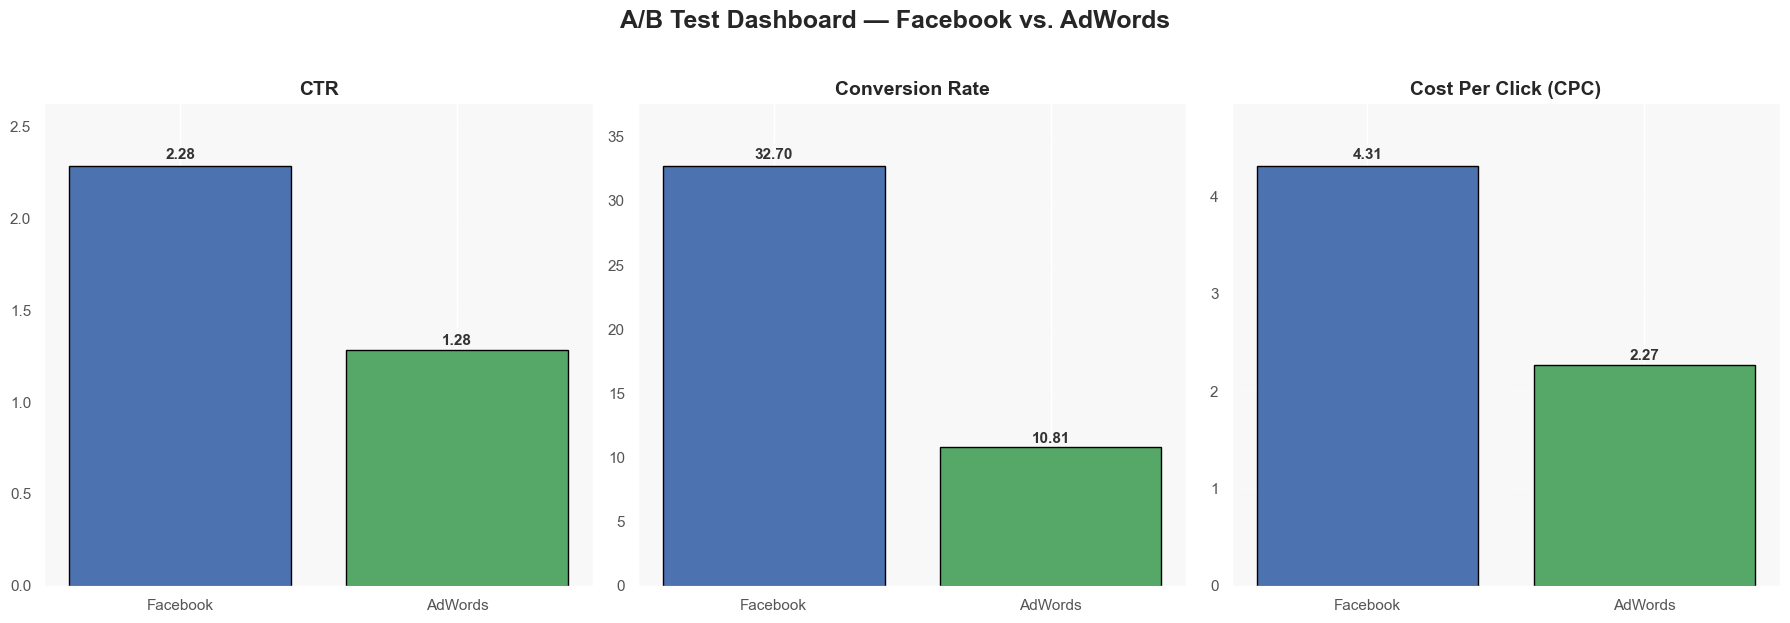

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
platforms = ["Facebook", "AdWords"]
ctr_vals = [facebook_ctr_mean, adwords_ctr_mean]
conv_vals = [facebook_conv_mean, adwords_conv_mean]
cpc_vals = [facebook_cpc_mean, adwords_cpc_mean]

metrics = {
    "CTR": ctr_vals,
    "Conversion Rate": conv_vals,
    "Cost Per Click (CPC)": cpc_vals
}

# Dashboard Style
plt.style.use("ggplot")  # soft background

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dashboard_colors = ["#4C72B0", "#55A868"]  # elegant colors

for ax, (metric_name, values) in zip(axes, metrics.items()):
    
    bars = ax.bar(
        platforms, 
        values,
        color=dashboard_colors,
        edgecolor="black",
        linewidth=1,
    )
    
    # Title for each chart
    ax.set_title(metric_name, fontsize=14, fontweight="bold")
    
    # Light y-grid (dashboard feel)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    
    # Add labels on every bar
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (height * 0.01),        # slight offset above bar
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color="#333333"
        )
    
    # Cleaner chart look
    ax.set_ylim(0, max(values) * 1.15)      # add space above bars
    ax.set_facecolor("#F8F8F8")             # light panel background

# Big dashboard title
fig.suptitle("A/B Test Dashboard — Facebook vs. AdWords", fontsize=18, fontweight="bold", y=1.03)

plt.tight_layout()
plt.show()
